In [1]:
import numpy as np
# import get_site_interactions
from matplotlib.path import Path
from scipy.signal import medfilt
from scipy.io import loadmat, savemat

In [2]:
''' Set root directory '''
root_dir = "Z:/Isabel/data/hpc_implants/" # locker
# root_dir = "C:/Users/ilow1/Documents/code/bird_pose_tracking/model_output/" # local - update as needed
bird_id = 'RBY94'
session_id = '241129'
session_root = f"{root_dir}{bird_id}/{bird_id}_{session_id}/"


''' Define paths to models, smoothed keypoints, arena info '''
pred_file = f'250109_posture_2stage_face.npy'
pred_path = f"{session_root}{pred_file}"

behavior_folder = f"{session_root}/behavior_data/"
pos_file = 'posture_pos_smooth.npy'
vel_file = 'posture_vel_smooth.npy'

arena_dir = 'C:/Users/ilow1/Documents/code/il_rig_control/arena_alignment/'
arena_items_file = 'arena_items_2.mat'

In [3]:
''' load the smoothed keypoints and calculate the foot speed '''
print('\nLoading smoothed postural keypoints and velocity...')
smooth_pts = np.load(f"{behavior_folder}{pos_file}") # n_frames, n_keypoints, 3
smooth_vel = np.load(f"{behavior_folder}{vel_file}")
foot_speed = np.sqrt(np.sum(np.mean(smooth_vel[:, [10, 14]], axis=1)**2, axis=1))

''' load the model output and get the body reprojection error '''
print('\nGetting reprojection error...')
results_dict = np.load(pred_path, allow_pickle=True).item()
results = results_dict['results']
body_reproj_error = results['com_rep_err'][:, 1]

''' load the arena objects '''
print('\nGetting arena objects...')
arena_data = loadmat(f'{arena_dir}{arena_items_file}', squeeze_me=True)
arena_data["perches"] = arena_data["perch_w_site"]
arena_data["feeder_perches"] = arena_data["perch_no_site"]


Loading smoothed postural keypoints and velocity...

Getting reprojection error...

Getting arena objects...


In [6]:
params = {
        "reproj_thresh": 10,  # Maximum reprojection error to count as a valid frame (pixels)
        "speed_thresh": 1/2,  # Threshold for feet 'not moving' (normalized units/second, e.g., output of Kalman filter)
        "cache_height_thresh": 0.023,  # Threshold for beak low enough for site interaction
        "merge_dur_thresh": 50,  # Threshold below which events at the same site *must* be merged (in frames at 50 fps)
        "feeder_height_thresh": 0.05,  # Threshold for beak low enough for feeder interaction
        # "feeder_radius_thresh": 1.75 / 13,  # Threshold for beak close enough to the center for feeder interaction
        "water_height_thresh": 0.06,  # Threshold for beak low enough for water interaction
        "water_radius_thresh": 0.625 / 13,  # Threshold for beak close enough to the center for water dish interaction
        "beak_foot_dist_thresh": 0.03,  # Distance threshold to count beak and feet near enough for eating
        # "cache_radius_tol": 1.005,  # Scale factor to adjust cache site locations (>1 means further from arena center) to better match the center of beak interactions
        "state_median_win": 5,  # Median window for filtering state status to prevent transient blips
    }

In [7]:
''' Calculate temporary variables '''
# beak and foot positions
beak_pos = np.mean(smooth_pts[:, [0, 1]], axis=1)  # avg beak position
foot_pos = np.mean(smooth_pts[:, [10, 14]], axis=1)  # avg foot position
beak_foot_dist = np.sqrt(np.sum((beak_pos - foot_pos)**2, axis=1))  # Euclidean dist beak to foot

# data params
n_frames = beak_pos.shape[0]  # Number of frames
n_cache_sites = len(arena_data["caches"])  # Number of cache sites
n_perches = len(arena_data["perches"])  # Number of perches
n_feeders = len(arena_data["feeder_perches"])  # Number of feeder perches

''' Utility indicators '''
valid_frames = body_reproj_error < params["reproj_thresh"]
feet_still = foot_speed < params["speed_thresh"]
beak_low_cache = beak_pos[:, 2] < params["cache_height_thresh"]
beak_low_feeder = beak_pos[:, 2] < params["feeder_height_thresh"]
beak_low_water = beak_pos[:, 2] < params["water_height_thresh"]
beak_low_feet = beak_foot_dist < params["beak_foot_dist_thresh"]
beak_radius_water = np.sqrt(np.sum(beak_pos[:, :2]**2, axis=1)) < params["water_radius_thresh"]

In [91]:
''' Detect interactions '''
print('\nDetecting perch interactions...')
# Feet on perches
feet_on_perch = np.zeros((n_frames, n_perches + n_feeders), dtype=bool)

for n in range(n_perches):
    print(f'cache perch {n+1}/{n_perches}')
    convex_hull = arena_data["perches"][n]["ConvexHull"]
    path = Path(convex_hull)
    tmp = path.contains_points(foot_pos[:, :2])  # Check if points are in polygon
    feet_on_perch[:, n] = tmp & feet_still & valid_frames

for n in range(n_feeders):
    print(f'feeder perch {n+1}/{n_feeders}')
    convex_hull = arena_data["feeder_perches"][n]["ConvexHull"]
    path = Path(convex_hull)
    tmp = path.contains_points(foot_pos[:, :2])
    feet_on_perch[:, n_perches + n] = tmp & feet_still & valid_frames


Detecting perch interactions...
cache perch 1/84
cache perch 2/84
cache perch 3/84
cache perch 4/84
cache perch 5/84
cache perch 6/84
cache perch 7/84
cache perch 8/84
cache perch 9/84
cache perch 10/84
cache perch 11/84
cache perch 12/84
cache perch 13/84
cache perch 14/84
cache perch 15/84
cache perch 16/84
cache perch 17/84
cache perch 18/84
cache perch 19/84
cache perch 20/84
cache perch 21/84
cache perch 22/84
cache perch 23/84
cache perch 24/84
cache perch 25/84
cache perch 26/84
cache perch 27/84
cache perch 28/84
cache perch 29/84
cache perch 30/84
cache perch 31/84
cache perch 32/84
cache perch 33/84
cache perch 34/84
cache perch 35/84
cache perch 36/84
cache perch 37/84
cache perch 38/84
cache perch 39/84
cache perch 40/84
cache perch 41/84
cache perch 42/84
cache perch 43/84
cache perch 44/84
cache perch 45/84
cache perch 46/84
cache perch 47/84
cache perch 48/84
cache perch 49/84
cache perch 50/84
cache perch 51/84
cache perch 52/84
cache perch 53/84
cache perch 54/84
cach

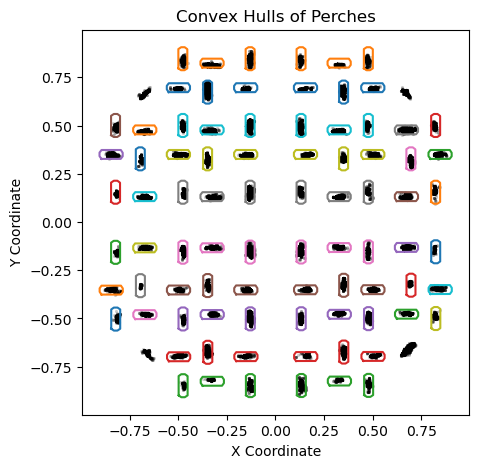

In [95]:
''' check the perch hulls '''
# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_title("Convex Hulls of Perches")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")

feet_on_perch_bool = np.sum(feet_on_perch_filt, axis=1).astype(bool)

# Plot each perch's convex hull
for n in range(n_perches):
    # print(f'Cache perch {n + 1}/{n_perches}')
    convex_hull = arena_data["perches"][n]["ConvexHull"]

    # Close the polygon for plotting (repeat the first point at the end)
    hull_closed = np.vstack([convex_hull, convex_hull[0]])

    # Plot the convex hull as a polygon
    ax.plot(hull_closed[:, 0], hull_closed[:, 1])

ax.scatter(foot_pos[feet_on_perch_bool, 0], foot_pos[feet_on_perch_bool, 1],
           s=5, c='k', lw=0, alpha=0.2)
plt.show()

In [96]:
# Median filter interactions
state_median_win = params["state_median_win"]
print(f"\n Median state filtering with {state_median_win} frames")
feet_on_perch = medfilt(feet_on_perch.astype(float), kernel_size=(state_median_win, 1)).astype(bool)


 Median state filtering with 5 frames


In [159]:
def detect_stateChanges_selfmerge(state_matrix):
    '''
    Determines the start and end time for each state change.
    Merges state changes when there is no state transition.
    
    Params
    ------
    state_array : bool, shape (n_frames, n_arena_objects)
    
    Returns
    -------
    onset_times : ndarray, shape (n_states, )
        state onset times (in frames)
    offset_times : ndarray, shape (n_states, )
        state offset times (in frames)
    obj_num : ndarray, shape (n_states, )
        arena object index
    '''
    # Count state changes, including start and final
    state_vector = np.any(state_matrix, axis=1)
    state_vector_padded = np.concatenate(([False], state_vector, [False])).astype(int)
    onset_times = np.where(np.diff(state_vector_padded) > 0.5)[0]
    offset_times = np.where(np.diff(state_vector_padded) < -0.5)[0]
    if offset_times[-1] == state_matrix.shape[0]:
        offset_times[-1] = offset_times[-1] - 1
        if offset_times[-1] == onset_times[-1]:
            onset_times[-1] = onset_times[-1] - 1
    
    # Check the number of states and the onset/offset times
    assert np.all(np.count_nonzero(state_matrix, axis=1) <= 1), "State includes more than one object at once!"
    obj_num = np.argmax(state_matrix[onset_times], axis=1)
    assert len(obj_num) == len(onset_times), "Every onset time must correspond to an object"
    assert np.all(offset_times - onset_times > 0.5), "Offset times precede onset times!"
    
    # Merge states that do not transition between different objects
    same_obj = np.where(np.diff(obj_num) == 0)[0]
    onset_times = np.delete(onset_times, same_obj + 1) # Remove the next entry (no state transition)
    offset_times = np.delete(offset_times, same_obj)  # Remove this exit (no state transition)
    
    # Check the number of states
    obj_num = np.argmax(state_matrix[onset_times], axis=1)
    assert len(obj_num) == len(onset_times), "Each state must correspond to an object"

    return onset_times, offset_times, obj_num

In [160]:
# Always merge perch interactions at the same site
new_perch, end_perch, perch_num = detect_stateChanges_selfmerge(feet_on_perch)

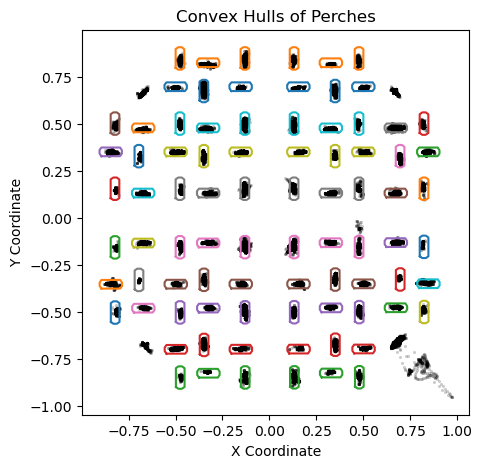

In [161]:
''' check the perch hulls '''
# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.set_title("Convex Hulls of Perches")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")

feet_on_perch_bool = np.sum(feet_on_perch_filt, axis=1).astype(bool)

# Plot each perch's convex hull
for n in range(n_perches):
    # print(f'Cache perch {n + 1}/{n_perches}')
    convex_hull = arena_data["perches"][n]["ConvexHull"]

    # Close the polygon for plotting (repeat the first point at the end)
    hull_closed = np.vstack([convex_hull, convex_hull[0]])

    # Plot the convex hull as a polygon
    ax.plot(hull_closed[:, 0], hull_closed[:, 1])

for t_start, t_end in zip(new_perch, end_perch):
    ax.scatter(foot_pos[t_start:t_end, 0], foot_pos[t_start:t_end, 1],
               s=5, c='k', lw=0, alpha=0.2)
plt.show()